In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)
plt.style.use('default')

In [2]:
df = pd.read_csv("Banking.csv")
df.head()

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,75384.77,17677.95,1,484.54,776242.92,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,289834.31,17398.92,1,2256.88,1270615.43,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,169935.23,42825.90,2,4568.74,1052715.84,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,356808.11,5473.15,2,4205.00,121195.06,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,130711.68,48077.60,1,3779.49,1048301.95,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [3]:
df.shape

(3000, 25)

In [4]:
df.isnull().sum()

Client ID                   0
Name                        0
Age                         0
Location ID                 0
Joined Bank                 0
Banking Contact             0
Nationality                 0
Occupation                  0
Fee Structure               0
Loyalty Classification      0
Estimated Income            0
Superannuation Savings      0
Amount of Credit Cards      0
Credit Card Balance         0
Bank Loans                  0
Bank Deposits               0
Checking Accounts           0
Saving Accounts             0
Foreign Currency Account    0
Business Lending            0
Properties Owned            0
Risk Weighting              0
BRId                        0
GenderId                    0
IAId                        0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

In [7]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Client ID,3000,2940,IND48103,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,3000,2913,Raymond Mills,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,3000.0,NaN,NaN,NaN,51.039667,19.85476,17.0,34.0,51.0,69.0,85.0
Location ID,3000.0,NaN,NaN,NaN,21563.323,12462.273017,12.0,10803.5,21129.5,32054.5,43369.0
Joined Bank,3000,2579,03-02-2020,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Banking Contact,3000,49,Ernest Rivera,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nationality,3000,5,European,1309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,3000,195,Structural Analysis Engineer,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fee Structure,3000,3,High,1476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Loyalty Classification,3000,4,Jade,1331,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Define income band boundaries
bins = [0, 100000, 300000, float('inf')]
labels = ['Low', 'Mid', 'High']

# Create the 'Income Band' column using pd.cut
df['Income Band'] = pd.cut(df['Estimated Income'], bins=bins, labels=labels, include_lowest=True)

In [9]:
# Examine the distribution of unique categories in categorical columns
categorical_cols = df[["Risk Weighting","Nationality","Occupation","Fee Structure","Loyalty Classification","Properties Owned","Risk Weighting","Occupation","Income Band"]].columns
for col in categorical_cols:
 
  print(f"\nValue Counts for '{col}':")
  display(df[col].value_counts())


Value Counts for 'Risk Weighting':


Risk Weighting
2    1222
1     836
3     460
4     322
5     160
Name: count, dtype: int64


Value Counts for 'Nationality':


Nationality
European      1309
Asian          754
American       507
Australian     254
African        176
Name: count, dtype: int64


Value Counts for 'Occupation':


...

Risk Weighting
2    1222
1     836
3     460
4     322
5     160
Name: count, dtype: int64


Value Counts for 'Occupation':


Occupation
Structural Analysis Engineer    28
Associate Professor             28
Recruiter                       25
Human Resources Manager         24
Account Coordinator             24
                                ..
Office Assistant IV              8
Automation Specialist I          7
Computer Systems Analyst I       6
Developer III                    5
Senior Sales Associate           4
Name: count, Length: 195, dtype: int64


Value Counts for 'Income Band':


Income Band
Mid     1517
Low     1027
High     456
Name: count, dtype: int64

In [10]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols

(Index(['Age', 'Location ID', 'Estimated Income', 'Superannuation Savings',
        'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
        'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
        'Foreign Currency Account', 'Business Lending', 'Properties Owned',
        'Risk Weighting', 'BRId', 'GenderId', 'IAId'],
       dtype='object'),
 Index(['Client ID', 'Name', 'Joined Bank', 'Banking Contact', 'Nationality',
        'Occupation', 'Fee Structure', 'Loyalty Classification'],
       dtype='object'))

In [11]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['client_id', 'name', 'age', 'location_id', 'joined_bank',
       'banking_contact', 'nationality', 'occupation', 'fee_structure',
       'loyalty_classification', 'estimated_income', 'superannuation_savings',
       'amount_of_credit_cards', 'credit_card_balance', 'bank_loans',
       'bank_deposits', 'checking_accounts', 'saving_accounts',
       'foreign_currency_account', 'business_lending', 'properties_owned',
       'risk_weighting', 'brid', 'genderid', 'iaid', 'income_band'],
      dtype='object')

In [12]:
cat_id_cols = [
    'location_id',
    'risk_weighting',
    'brid',
    'genderid',
    'iaid'
]

df[cat_id_cols] = df[cat_id_cols].astype('object')
df[cat_id_cols].dtypes

location_id       object
risk_weighting    object
brid              object
genderid          object
iaid              object
dtype: object

In [13]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols

(Index(['age', 'estimated_income', 'superannuation_savings',
        'amount_of_credit_cards', 'credit_card_balance', 'bank_loans',
        'bank_deposits', 'checking_accounts', 'saving_accounts',
        'foreign_currency_account', 'business_lending', 'properties_owned'],
       dtype='object'),
 Index(['client_id', 'name', 'location_id', 'joined_bank', 'banking_contact',
        'nationality', 'occupation', 'fee_structure', 'loyalty_classification',
        'risk_weighting', 'brid', 'genderid', 'iaid'],
       dtype='object'))

In [14]:
df['gender'] = df['genderid'].map({
    1: 'Male',
    2: 'Female'
})
df['gender'].head()

0      Male
1      Male
2    Female
3      Male
4    Female
Name: gender, dtype: object

In [15]:
df['banking_relationship'] = df['brid'].map({
    1: 'Retail',
    2: 'Institutional',
    3: 'Private Bank',
    4: 'Commercial'
})
df['banking_relationship'].head(10)

0           Retail
1    Institutional
2     Private Bank
3       Commercial
4           Retail
5           Retail
6           Retail
7    Institutional
8    Institutional
9     Private Bank
Name: banking_relationship, dtype: object

In [16]:
iaid_mapping = {
    1: 'Victor Dean',
    2: 'Jeremy Porter',
    3: 'Ernest Knight',
    4: 'Eric Shaw',
    5: 'Kevin Kim',
    6: 'Victor Rogers',
    7: 'Eugene Cunningham',
    8: 'Joe Carroll',
    9: 'Steve Sanchez',
    10: 'Lawrence Sanchez',
    11: 'Peter Castillo',
    12: 'Victor Gutierrez',
    13: 'Daniel Carroll',
    14: 'Carl Anderson',
    15: 'Nicholas Ward',
    16: 'Fred Bryant',
    17: 'Ryan Taylor',
    18: 'Sean Vasquez',
    19: 'Nicholas Morrison',
    20: 'Jack Phillips',
    21: 'Juan Ramirez',
    22: 'Gregory Boyd'
}

df['investment_advisor'] = df['iaid'].map(iaid_mapping)
df['investment_advisor'].head(10)

0          Victor Dean
1        Jeremy Porter
2        Ernest Knight
3            Eric Shaw
4            Kevin Kim
5        Victor Rogers
6    Eugene Cunningham
7          Joe Carroll
8        Steve Sanchez
9     Lawrence Sanchez
Name: investment_advisor, dtype: object

In [17]:
df.drop(columns=['genderid', 'brid', 'iaid'], inplace=True)
df.head()

,client_id,name,age,location_id,joined_bank,banking_contact,nationality,occupation,fee_structure,loyalty_classification,estimated_income,superannuation_savings,amount_of_credit_cards,credit_card_balance,bank_loans,bank_deposits,checking_accounts,saving_accounts,foreign_currency_account,business_lending,properties_owned,risk_weighting,income_band,gender,banking_relationship,investment_advisor
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,75384.77,17677.95,1,484.54,776242.92,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,Low,Male,Retail,Victor Dean
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,289834.31,17398.92,1,2256.88,1270615.43,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,Mid,Male,Institutional,Jeremy Porter
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,169935.23,42825.90,2,4568.74,1052715.84,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,Mid,Female,Private Bank,Ernest Knight
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,356808.11,5473.15,2,4205.00,121195.06,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,High,Male,Commercial,Eric Shaw
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,130711.68,48077.60,1,3779.49,1048301.95,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,Mid,Female,Retail,Kevin Kim


In [19]:
df['joined_bank'] = pd.to_datetime(df['joined_bank'], format='%d-%m-%Y')
print(df['joined_bank'].dtype)

datetime64[ns]


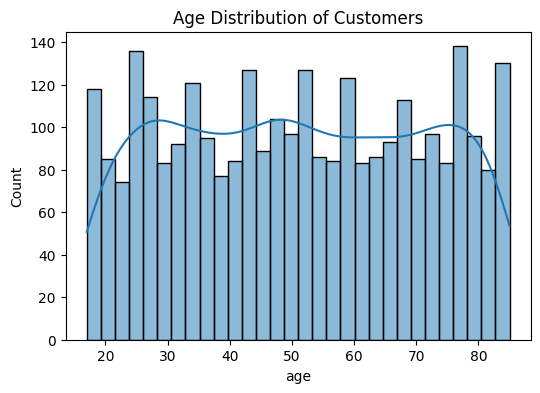

In [20]:
# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution of Customers")
plt.show()

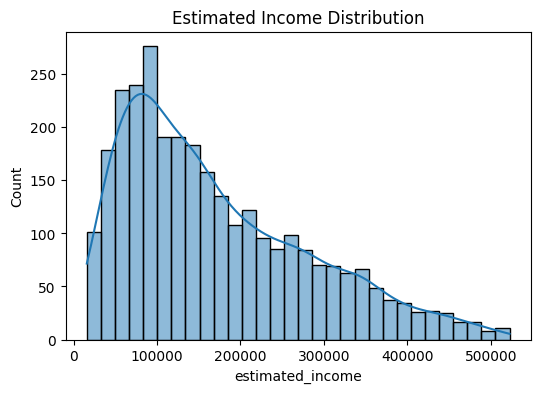

In [21]:
# Income Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['estimated_income'], bins=30, kde=True)
plt.title("Estimated Income Distribution")
plt.show()

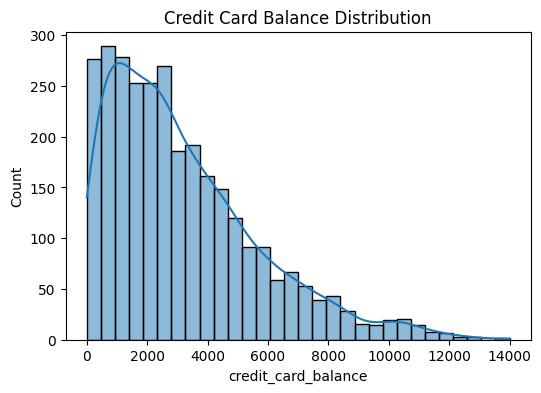

In [22]:
# Credit Card Balance
plt.figure(figsize=(6,4))
sns.histplot(df['credit_card_balance'], bins=30, kde=True)
plt.title("Credit Card Balance Distribution")
plt.show()

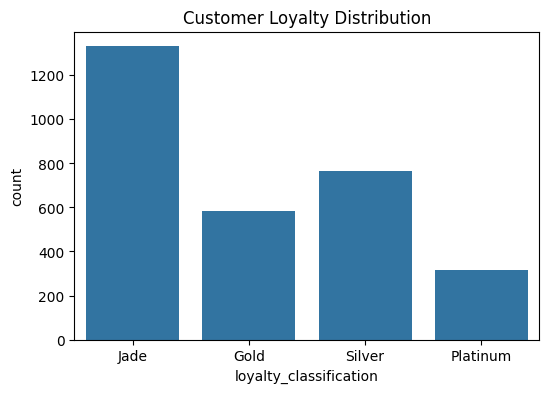

In [23]:
# Loyalty Classification
df['loyalty_classification'].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(x='loyalty_classification', data=df)
plt.title("Customer Loyalty Distribution")
plt.show()

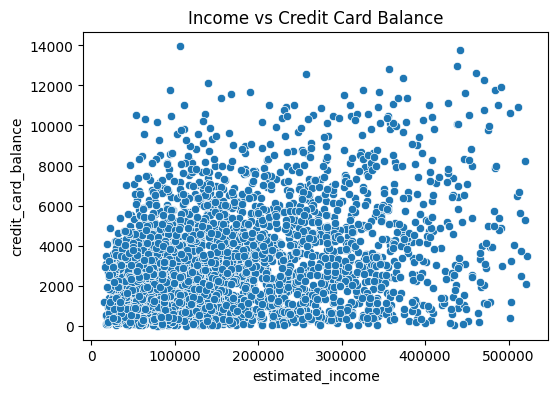

In [24]:
# Occupation Analysis
df['occupation'].value_counts().head(10)

plt.figure(figsize=(6,4))
sns.scatterplot(x='estimated_income', y='credit_card_balance', data=df)
plt.title("Income vs Credit Card Balance")
plt.show()

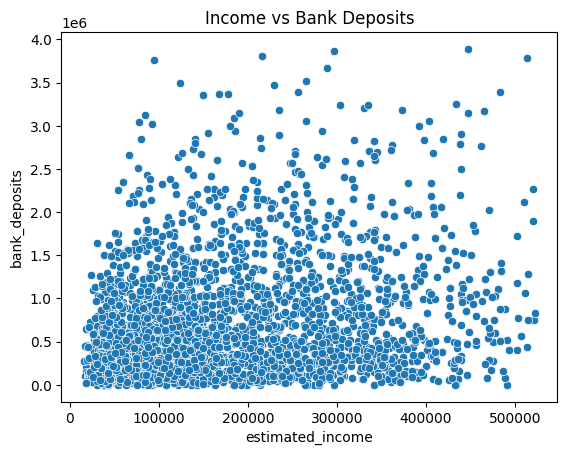

In [25]:
# Income vs Bank Deposits
sns.scatterplot(x='estimated_income', y='bank_deposits', data=df)
plt.title("Income vs Bank Deposits")
plt.show()

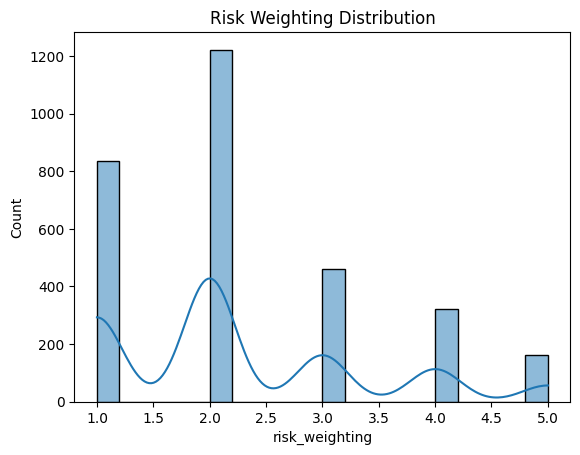

In [26]:
# Risk Weighting Distribution
sns.histplot(df['risk_weighting'], bins=20, kde=True)
plt.title("Risk Weighting Distribution")
plt.show()


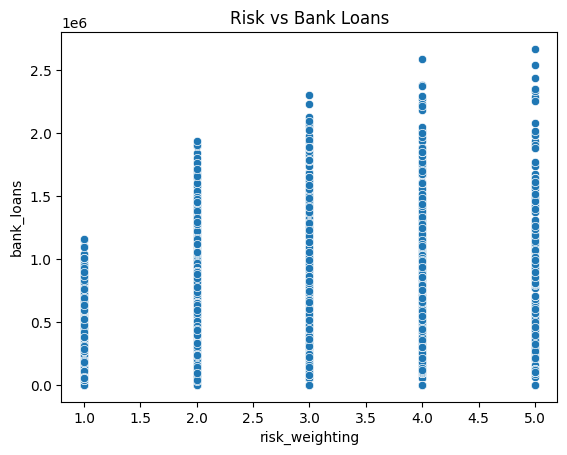

In [27]:
# Risk vs Loan Amount
sns.scatterplot(x='risk_weighting', y='bank_loans', data=df)
plt.title("Risk vs Bank Loans")
plt.show()

In [28]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# Step 1: Connect to MySQL
username = "root"      
password = quote_plus("Dinesh@007") # the password you set during installation
host = "localhost"         # if running locally
port = "3306"              # default MySQl port
database = "banking_customer_analytics"    # MySQL database

engine = create_engine(f"mysql+mysqlconnector://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into MySQl
table_name = "banking"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'banking' in database 'banking_customer_analytics'.
